## LOAD THE PACKAGES

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
from scipy.stats import pearsonr
import insightface
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import joblib
import warnings

warnings.filterwarnings('ignore')


C:\Users\Dhanush Ramachandran\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
import importlib.metadata

packages = [
    "numpy", 
    "pandas", 
    #"opencv-python",  # Note: The pip package name is opencv-python, not cv2
    "tqdm", 
    "scikit-learn",   # Note: The pip package name is scikit-learn, not sklearn
    "xgboost", 
    "scipy", 
    "insightface", 
    "joblib"
]

for pkg in packages:
    try:
        version = importlib.metadata.version(pkg)
        print(f"{pkg}=={version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{pkg}: NOT FOUND in this kernel's environment")

numpy==2.4.4
pandas==3.0.2
tqdm==4.67.3
scikit-learn==1.8.0
xgboost==3.2.0
scipy==1.17.1
insightface==0.7.3
joblib==1.5.3


## INSTALL ADDITIONAL DEPENDENCIES

In [2]:
!pip install xgboost 

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.7/101.7 MB 31.8 MB/s eta 0:00:04
   ----- ---------------------------------- 14.9/101.7 MB 40.9 MB/s eta 0:00:03
   ---------- ----------------------------- 26.5/101.7 MB 45.4 MB/s eta 0:00:02
   -------------- ------------------------- 37.5/101.7 MB 47.7 MB/s eta 0:00:02
   ----------------- ---------------------- 44.0/101.7 MB 44.5 MB/s eta 0:00:02
   --------------------- ------------------ 53.7/101.7 MB 45.1 MB/s eta 0:00:02
   ---------------------- ----------------- 57.7/101.7 MB 41.3 MB/s eta 0:00:02
   -------------------------- ------------- 66.8/101.7 MB 41.0 MB/s eta 0:00:01
   ------------------------------ --------- 76.8/101.7 MB 41.9 MB/s eta 0:00:01
   --------------------------------- ------ 86.2/101.7 MB 42.3 MB/s eta 0:00:01
   ------------------------------------- -- 96.2/101

In [4]:
!pip install insightface 

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached cython-3.2.4-cp311-cp311-win_amd64.whl.metadata (7.7 kB)
Using cached cython-3.2.4-cp311-cp311-win_amd64.whl (2.8 MB)
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ------------------- -------------------- 8.1/16.4 MB 38.6 MB/s eta 0:00:01
   -------------------------------------- - 16.0/16.4 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 35.6 MB/s  0:00:00
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ----------------------------- ---------- 8.7/11.9 MB 44.9 MB/s eta 0:00:01
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [12]:
data.head()

,Unnamed: 0,bmi,gender,is_training,name,bmi_category
0,0,34.207396,Male,1,img_0.bmp,Obese
1,1,26.453720,Male,1,img_1.bmp,Overweight
2,2,34.967561,Female,1,img_2.bmp,Obese
3,3,22.044766,Female,1,img_3.bmp,Normal
4,4,37.758789,Female,1,img_4.bmp,Obese


## DATA LOADING

In [4]:
# Load augmented dataset
data = pd.read_csv('data_augmented_balanced.csv')

In [5]:
data['full_path'] = data['name'].apply(lambda x: os.path.join("BMI\BMI\Data\Images", x))
data = data[data['full_path'].apply(os.path.exists)].reset_index(drop=True)
data['is_training'] = data['is_training'].astype(bool)

print("Loaded data shape:", data.shape)

Loaded data shape: (7777, 7)


## LOAD THE MODEL

In [ ]:
data.shape 
model_arcface = insightface.app.FaceAnalysis(name='buffalo_l') 
model_arcface.prepare(ctx_id=0, det_size=(224, 224)) 

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Dhanush Ramachandran/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Dhanush Ramachandran/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Dhanush Ramachandran/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Dhanush Ramachandran/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Dhanush Ramachandran/.insight

## EMBEDDING EXTRACTION

In [ ]:

def get_arcface_embedding(img_path):
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces = model_arcface.get(img)
        if faces:
            return faces[0].embedding  
        else:
            return None
    except:
        return None

In [ ]:

print("Extracting ArcFace embeddings")
X, y = [], []
successful_rows = []
missing_files = []

for idx, row in tqdm(data.iterrows(), total=len(data)):
    embedding = get_arcface_embedding(row['full_path'])
    if embedding is not None:
        X.append(embedding)
        y.append(row['bmi'])
        successful_rows.append(idx)  
    else:
        missing_files.append(row['full_path'])

X = np.array(X)
y = np.array(y)

data_filtered = data.loc[successful_rows].reset_index(drop=True)

print(f"Total missing faces: {len(missing_files)}")
if missing_files:
    print("Missing files:", missing_files)

# Now shapes match
print("Filtered data shape:", data_filtered.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Extracting ArcFace embeddings...


  0%|          | 0/7777 [00:00<?, ?it/s]

100%|██████████| 7777/7777 [41:03<00:00,  3.16it/s]

Total missing faces: 2
Missing files: ['BMI\\BMI\\Data\\Images\\img_77.bmp', 'BMI\\BMI\\Data\\Images\\aug_94d9a61d_img_77.bmp']
Filtered data shape: (7775, 7)
X shape: (7775, 512)
y shape: (7775,)


## TRAIN/TEST SPLITS

In [ ]:
np.save("face_embeddings_arcface_1.npy", X) 

In [25]:
# Train/Test Split 
data_filtered = pd.read_csv(r"df_res_emb.csv") 
is_train = data_filtered['is_training'].values
X_train, X_test = X[is_train], X[~is_train]
y_train, y_test = y[is_train], y[~is_train]
gender_test = data_filtered[~data_filtered['is_training']]['gender'].values

In [ ]:
gender_test = data_filtered[~data_filtered['is_training']]['gender'].values

## xgboost

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define XGBoost + Grid Search
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [500,700],
    'max_depth': [5, 7,9],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.9]
    #'colsample_bytree': [0.7, 0.9]
}

grid = GridSearchCV(
    xgb_model,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=3,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_
print("Best Params:", grid.best_params_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [8]:
# Evaluate
print("---"*8)
print("OVERALL PRECISION METRICS")
y_pred = best_xgb.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))
print("---"*8)

------------------------
OVERALL PRECISION METRICS
MAE: 3.2371167184621954
RMSE: 4.378921426155122
R²: 0.7741275272965386
------------------------


In [10]:
# Predict
y_pred = best_xgb.predict(X_test)
print("---"*8)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
r, _ = pearsonr(y_test, y_pred)
print("Overall Pearson r:", r)
print("---"*8)
mask_male = (gender_test == 'Male') | (gender_test == 'male')
mask_female = (gender_test == 'Female') | (gender_test == 'female')

if mask_male.sum() > 0:
    r_male, _ = pearsonr(y_test[mask_male], y_pred[mask_male])
    print("Male Pearson r:", r_male)

if mask_female.sum() > 0:
    r_female, _ = pearsonr(y_test[mask_female], y_pred[mask_female])
    print("Female Pearson r:", r_female)

------------------------
MAE: 3.2371167184621954
R²: 0.7741275272965386
RMSE: 4.3789
Overall Pearson r: 0.8917553584156246
------------------------
Male Pearson r: 0.8921014273599525
Female Pearson r: 0.8938633052333236


In [ ]:
import joblib 
best_xgb = joblib.load("best_xgb_model.pkl") 

In [3]:
joblib.dump(best_xgb, "best_xgb_model_1.joblib")
print("Model saved successfully!")

Model saved successfully!


## SVR MODEL

In [33]:
# Define SVR + Grid Search
svr = SVR(kernel='rbf')
param_grid = { 
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.5],
    'gamma': ['scale', 'auto']
}
grid = GridSearchCV(
    svr,
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=3,
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)
best_svr = grid.best_estimator_
print("Best Params:", grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}


In [ ]:
import joblib 
best_svr = joblib.load("ARCFACE_MODEL_FINAL.joblib") 


## PREDICTION

In [18]:
# Predict
y_pred = best_svr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
r, _ = pearsonr(y_test, y_pred)
print("Overall Pearson r:", r)

mask_male = (gender_test == 'Male') | (gender_test == 'male')
mask_female = (gender_test == 'Female') | (gender_test == 'female')

if mask_male.sum() > 0:
    r_male, _ = pearsonr(y_test[mask_male], y_pred[mask_male])
    print("Male Pearson r:", r_male)

if mask_female.sum() > 0:
    r_female, _ = pearsonr(y_test[mask_female], y_pred[mask_female])
    print("Female Pearson r:", r_female)

MAE: 2.852004554346427
R²: 0.761548997281388
RMSE: 4.4992
Overall Pearson r: 0.8744311250161514
Male Pearson r: 0.8717516313797826
Female Pearson r: 0.8783608811006944


### STORE IN RESULTANT DATAFRAMES

In [11]:
df_res = data.copy() 

In [ ]:
y_pred.shape 

(752,)

### merge the outputs

In [34]:
X_embeddings = np.vstack(df_res["arc_face_embeddings"].values)

df_res["bmi_pred_xgb"] = best_xgb.predict(X_embeddings)

In [39]:
y_pred_train = df_res[df_res["is_training"]]["bmi_pred_xgb"].to_numpy() 

In [40]:
y_pred_test = df_res[~df_res["is_training"]]["bmi_pred_xgb"].to_numpy()

In [41]:
y_pred_all = np.concatenate([np.reshape(y_pred, (-1, 1)), np.reshape(y_pred_train, (-1, 1))], axis=0)
print(y_pred_all.shape) 

(7775, 1)


### clean df

In [13]:
df_res.columns

Index(['Unnamed: 0', 'bmi', 'gender', 'is_training', 'name', 'bmi_category',
       'full_path'],
      dtype='str')

### add predictions

In [42]:
import numpy as np

pred_dim = 1
all_preds = np.empty((len(df_res), pred_dim), dtype=object)

# Map the training and test matrices directly into their respective index spaces
all_preds[df_res["is_training"] == True] = y_pred_train.reshape(-1,1)
all_preds[df_res["is_training"] == False] = y_pred.reshape(-1,1)

# Convert the rows to a list and assign it as a single flat column
df_res["bmi_pred"] = list(all_preds)

In [16]:
df_res = pd.read_csv("df_res_emb.csv")

In [ ]:
df_res.dtypes 

Unnamed: 0.1             int64
Unnamed: 0               int64
bmi                    float64
gender                     str
is_training               bool
name                       str
bmi_category               str
full_path                  str
bmi_pred                   str
arc_face_embeddings     object
dtype: object

In [20]:
import numpy as np

def parse_space_separated_embedding(x):
    # Check for NaN or empty values
    if not isinstance(x, str) or not x.strip():
        return np.nan
    
    # Strip the brackets and clean up extra whitespace/newlines
    cleaned = x.replace('[', '').replace(']', '').strip()
    
    # Convert space-separated string directly to a numpy array of floats
    return np.fromstring(cleaned, sep=' ')

# Apply the fix
df_res["arc_face_embeddings"] = df_res["arc_face_embeddings"].apply(parse_space_separated_embedding)

In [24]:
X = df_res["arc_face_embeddings"].to_numpy()
y = df_res["bmi"].to_numpy()

### add embeddings

In [ ]:
import numpy as np

embedding_dim = X_train.shape[1]
all_embeddings = np.empty((len(df_res), embedding_dim), dtype=object)

all_embeddings[df_res["is_training"] == True] = X_train
all_embeddings[df_res["is_training"] == False] = X_test

df_res["arc_face_embeddings"] = list(all_embeddings)

In [ ]:
xx = df_res["bmi_pred"].head().tolist() 

In [ ]:
df_res["arc_face_embeddings"] 

0       [-0.6332581639289856, 0.7545194029808044, 0.58...
1       [1.1630393266677856, -0.6311432719230652, 2.62...
2       [0.5946192145347595, -0.9398502707481384, 0.04...
3       [1.327978253364563, -0.9427202939987183, 1.145...
4       [1.911557674407959, 1.0386801958084106, 0.1313...
                              ...                        
7772    [0.8654516935348511, 1.1487393379211426, -0.30...
7773    [0.28808853030204773, -0.6648889780044556, -0....
7774    [0.2851865589618683, 1.094265341758728, 0.9073...
7775    [0.9434524774551392, 0.11870871484279633, -0.9...
7776    [-1.6712759733200073, -0.5541501641273499, 1.1...
Name: arc_face_embeddings, Length: 7775, dtype: object

### save the results

In [ ]:
df_res.to_csv("df_res_emb.csv")

In [107]:
joblib.dump(best_svr, "ARCFACE_MODEL_FINAL.joblib")

['ARCFACE_MODEL_FINAL.joblib']

In [37]:
np.save("arc_face_1/X_train_arcface_augmented.npy", X_train)
np.save("arc_face_1/X_test_arcface_augmented.npy", X_test)
np.save("arc_face_1/y_train_arcface_augmented.npy", y_train)
np.save("arc_face_1/y_test_arcface_augmented.npy", y_test)
np.save("arc_face_1/gender_test_arcface_augmented.npy", gender_test)

## Tests results and Analysis

In [43]:
test_res_df = df_res[~df_res["is_training"]]

In [44]:
test_res_df.columns 

Index(['Unnamed: 0.1', 'Unnamed: 0', 'bmi', 'gender', 'is_training', 'name',
       'bmi_category', 'full_path', 'bmi_pred', 'arc_face_embeddings',
       'bmi_pred_xgb'],
      dtype='str')

In [45]:
result_df = test_res_df

In [46]:
result_df.head()
result_df["bmi_pred"] = result_df["bmi_pred"].apply(lambda x: x[0])
result_df["bmi_pred"] = result_df["bmi_pred"].astype(float)
result_df["bmi"] = result_df["bmi"].astype(float)


  OVERALL PREDICTION METRICS
  MAE  : 3.2371
  RMSE : 4.3789
  R²   : 0.7741

  PER-GENDER METRICS
---------------------------------------------
  Gender : Female  (n=325)
    MAE=3.3781  RMSE=4.6292  R²=0.7622  Bias=+0.0723
  Gender : Male  (n=427)
    MAE=3.1298  RMSE=4.1784  R²=0.7831  Bias=-0.2886

  ERROR DISTRIBUTION BY GENDER
---------------------------------------------
        count    mean     std     min     25%     50%     75%      max
gender                                                                
Female  325.0  3.3781  3.1700  0.0218  1.0865  2.7478  4.7492  27.2200
Male    427.0  3.1298  2.7715  0.0198  1.2038  2.5475  4.3629  29.9589

  MAE BY BMI RANGE & GENDER
---------------------------------------------
gender      Female    Male
bmi_bin                   
Normal      3.1889  2.1086
Overweight  3.5706  3.1743
Obese I     2.1439  2.5652
Obese II    3.8480  3.6792
Obese III   4.3804  3.7411


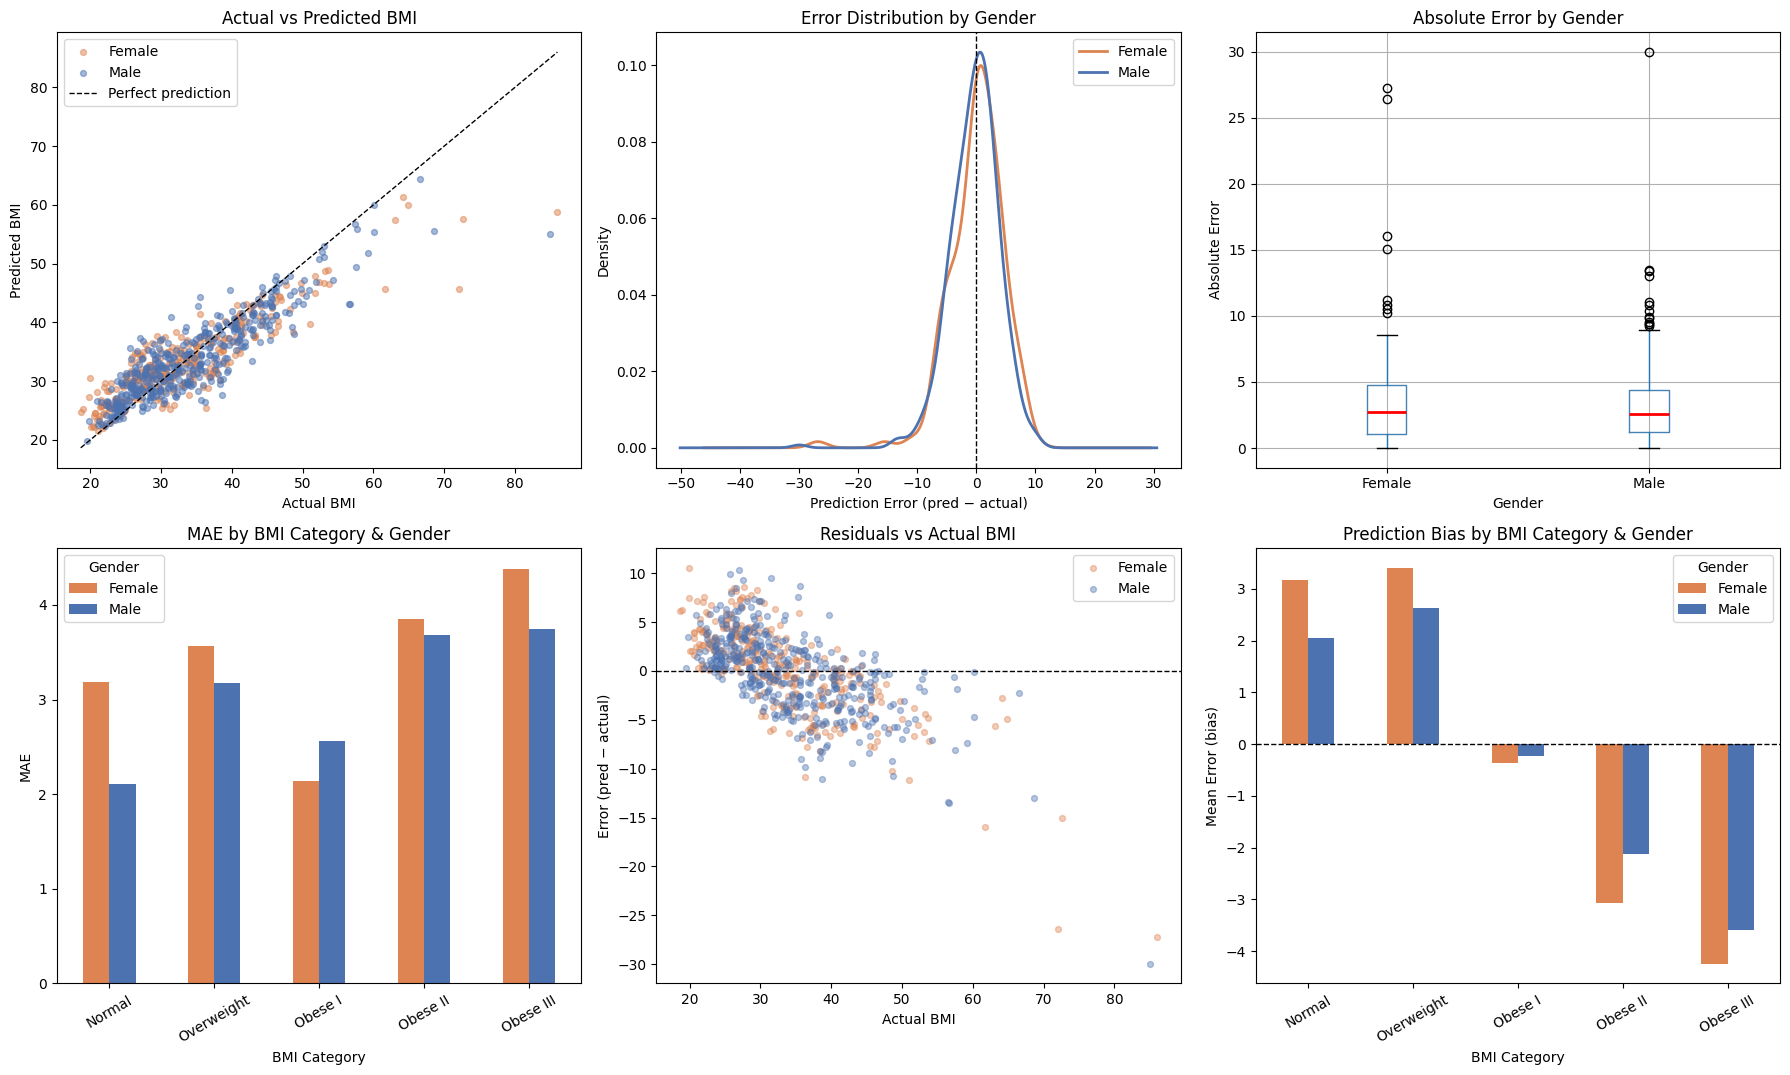


Plot saved → bmi_post_prediction_analysis.png

  TRAIN vs TEST — MAE BY GENDER
---------------------------------------------
gender       Female    Male
is_training                
Test         3.3781  3.1298


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── 1. Basic Error Metrics 
result_df['error']     = result_df['bmi_pred'] - result_df['bmi']
result_df['abs_error'] = result_df['error'].abs()

mae  = mean_absolute_error(result_df['bmi'], result_df['bmi_pred'])
rmse = np.sqrt(mean_squared_error(result_df['bmi'], result_df['bmi_pred']))
r2   = r2_score(result_df['bmi'], result_df['bmi_pred'])

print("=" * 45)
print("  OVERALL PREDICTION METRICS")
print("=" * 45)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 45)


# ── 2. Per-Gender Metrics ─────────────────────────────────────────────────────
print("\n  PER-GENDER METRICS\n" + "-" * 45)
for gender, grp in result_df.groupby('gender'):
    g_mae  = mean_absolute_error(grp['bmi'], grp['bmi_pred'])
    g_rmse = np.sqrt(mean_squared_error(grp['bmi'], grp['bmi_pred']))
    g_r2   = r2_score(grp['bmi'], grp['bmi_pred'])
    g_bias = grp['error'].mean()          # systematic over/under prediction
    print(f"  Gender : {gender}  (n={len(grp)})")
    print(f"    MAE={g_mae:.4f}  RMSE={g_rmse:.4f}  R²={g_r2:.4f}  Bias={g_bias:+.4f}")


# ── 3. Per-Gender Error Distribution 
print("\n  ERROR DISTRIBUTION BY GENDER\n" + "-" * 45)
print(result_df.groupby('gender')['abs_error'].describe().round(4))


# ── 4. BMI Range Binning & Accuracy per Bin 
result_df['bmi_bin'] = pd.cut(
    result_df['bmi'],
    bins=[0, 18.5, 25, 30, 35, 40, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese I', 'Obese II', 'Obese III']
)

print("\n  MAE BY BMI RANGE & GENDER\n" + "-" * 45)
bin_gender_mae = (
    result_df.groupby(['bmi_bin', 'gender'])['abs_error']
    .mean()
    .unstack('gender')
    .round(4)
)
print(bin_gender_mae)


#  5. Visualisations 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Post-Prediction Analysis — BMI vs Gender", fontsize=16, fontweight='bold')

colors = {'Male': '#4C72B0', 'Female': '#DD8452'}   # adjust keys to match your data

# 5a. Actual vs Predicted (by gender)
ax = axes[0, 0]
for gender, grp in result_df.groupby('gender'):
    ax.scatter(grp['bmi'], grp['bmi_pred'],
               label=gender, alpha=0.5, s=18, color=colors.get(gender))
lims = [result_df[['bmi', 'bmi_pred']].min().min(),
        result_df[['bmi', 'bmi_pred']].max().max()]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual BMI')
ax.set_ylabel('Predicted BMI')
ax.set_title('Actual vs Predicted BMI')
ax.legend()

# 5b. Error Distribution by Gender (KDE)
ax = axes[0, 1]
for gender, grp in result_df.groupby('gender'):
    grp['error'].plot.kde(ax=ax, label=gender, color=colors.get(gender), linewidth=2)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Prediction Error (pred − actual)')
ax.set_title('Error Distribution by Gender')
ax.legend()

# 5c. Box-plot of Absolute Error by Gender
ax = axes[0, 2]
result_df.boxplot(column='abs_error', by='gender', ax=ax,
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
ax.set_title('Absolute Error by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Absolute Error')
plt.sca(ax); plt.title('Absolute Error by Gender'); plt.suptitle('')

# 5d. MAE per BMI Category & Gender (grouped bar)
ax = axes[1, 0]
bin_gender_mae.plot(kind='bar', ax=ax, color=[colors.get(c, 'grey') for c in bin_gender_mae.columns])
ax.set_title('MAE by BMI Category & Gender')
ax.set_xlabel('BMI Category')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Gender')

# 5e. Residual vs Actual BMI (by gender)
ax = axes[1, 1]
for gender, grp in result_df.groupby('gender'):
    ax.scatter(grp['bmi'], grp['error'],
               label=gender, alpha=0.4, s=18, color=colors.get(gender))
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Actual BMI')
ax.set_ylabel('Error (pred − actual)')
ax.set_title('Residuals vs Actual BMI')
ax.legend()

# 5f. Mean Error (Bias) per BMI Bin & Gender
ax = axes[1, 2]
bias_table = (
    result_df.groupby(['bmi_bin', 'gender'])['error']
    .mean()
    .unstack('gender')
)
bias_table.plot(kind='bar', ax=ax, color=[colors.get(c, 'grey') for c in bias_table.columns])
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Prediction Bias by BMI Category & Gender')
ax.set_xlabel('BMI Category')
ax.set_ylabel('Mean Error (bias)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Gender')

plt.tight_layout()
plt.savefig('bmi_post_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → bmi_post_prediction_analysis.png")


if 'is_training' in result_df.columns:
    print("\n  TRAIN vs TEST — MAE BY GENDER\n" + "-" * 45)
    split_gender = (
        result_df.groupby(['is_training', 'gender'])['abs_error']
        .mean()
        .unstack('gender')
        .rename(index={True: 'Train', False: 'Test'})
        .round(4)
    )
    print(split_gender)

In [48]:
df_res["bmi_category"].value_counts()

bmi_category
Underweight       1622
Normal            1583
Overweight        1544
Severely Obese    1516
Obese             1510
Name: count, dtype: int64

## LOAD SAVED DATA

In [3]:
import numpy as np

X_train = np.load("arc_face_1_emb/X_train_arcface_augmented.npy")
X_test = np.load("arc_face_1_emb/X_test_arcface_augmented.npy")
y_train = np.load("arc_face_1_emb/y_train_arcface_augmented.npy")
y_test = np.load("arc_face_1_emb/y_test_arcface_augmented.npy")